In [95]:

import sys
import logging
sys.path.append('E:\wangzhilin\QuantumGalaxy')
from QGI.mysql import MYSQL

import pandas as pd
import numpy as np
from QGI.neoapi import Neo4j
from QGI.feishu import *
import os
def get_logger(name,level=None,file=None):
    logger=logging.getLogger(name)
    logger.setLevel(logging.INFO)
    
    ch=logging.StreamHandler()
    ch.setLevel(logging.INFO)
    formatter=logging.Formatter(fmt='%(asctime)s %(name)-12s %(levelname)-8s %(message)s',datefmt='%m-%d %H:%M')
    ch.setFormatter(formatter)
    
    logger.addHandler(ch)
    if file:    
        fh=logging.FileHandler("E:/wangzhilin/QuantumGalaxy/logs/%s.log"%file,'a',encoding='utf-8')
        fh.setLevel(logging.INFO)
        fh.setFormatter(formatter)
        logger.addHandler(fh)
    return logger
logger=get_logger('logger')
uri = "neo4j+ssc://08ef0a79.databases.neo4j.io"
user = "QG_Editor"
password = "editor"
neo=Neo4j(uri,user,password)


Failed to write data to connection ResolvedIPv4Address(('34.126.114.186', 7687)) (IPv4Address(('34.126.114.186', 7687)))
Failed to write data to connection IPv4Address(('08ef0a79.databases.neo4j.io', 7687)) (IPv4Address(('34.126.114.186', 7687)))


In [96]:
backbone='煤炭'
cypher='match (n) where n.backbone contains "%s" return n.name,labels(n)'%backbone
nodes=neo.read_query(cypher)
cypher='match p=(n1)-[r]->(n2) where n1.backbone contains "%s" and n2.backbone contains "%s" return startNode(r).name,endNode(r).name,type(r)'%(backbone,backbone)
edges=neo.read_query(cypher)

09-07 11:35 logger       INFO     accept cypher query match (n) where n.backbone contains "煤炭" return n.name,labels(n)
09-07 11:35 logger       INFO     accept cypher query match (n) where n.backbone contains "煤炭" return n.name,labels(n)
09-07 11:35 logger       INFO     get 20 records
09-07 11:35 logger       INFO     get 20 records
09-07 11:35 logger       INFO     accept cypher query match p=(n1)-[r]->(n2) where n1.backbone contains "煤炭" and n2.backbone contains "煤炭" return startNode(r).name,endNode(r).name,type(r)
09-07 11:35 logger       INFO     accept cypher query match p=(n1)-[r]->(n2) where n1.backbone contains "煤炭" and n2.backbone contains "煤炭" return startNode(r).name,endNode(r).name,type(r)
09-07 11:35 logger       INFO     get 20 records
09-07 11:35 logger       INFO     get 20 records


In [97]:
edges[0]

<Record startNode(r).name='合成氨' endNode(r).name='尿素' type(r)='compose'>

In [105]:
nodes[0]

<Record n.name='合成氨' labels(n)=['Product']>

In [98]:
nodes[0].values()

['合成氨', ['Product']]

In [596]:
import matplotlib.pyplot as plt
import networkx as nx
import random
import matplotlib as mpl
import json
G=nx.DiGraph()
for node in nodes:
    G.add_node(node[0],**node[1:])
for edge in edges:
    G.add_edge(edge[0],edge[1],relationship=edge[2],)
for u,v,d in G.edges(data=True):
    if d['relationship']=='compose':
        G.edges[u,v]['velocity']=random.randrange(10,100)
    else:
        G.edges[u,v]['velocity']=0
for n,d in G.nodes(data=True):
    if 'Product' in d['labels(n)']:
        G.nodes[n]['stock']=random.randrange(10,100)
    else:
        G.nodes[n]['stock']=0

In [606]:
import numpy as np
np.sin(range(1,101))

array([ 0.84147098,  0.90929743,  0.14112001, -0.7568025 , -0.95892427,
       -0.2794155 ,  0.6569866 ,  0.98935825,  0.41211849, -0.54402111,
       -0.99999021, -0.53657292,  0.42016704,  0.99060736,  0.65028784,
       -0.28790332, -0.96139749, -0.75098725,  0.14987721,  0.91294525,
        0.83665564, -0.00885131, -0.8462204 , -0.90557836, -0.13235175,
        0.76255845,  0.95637593,  0.27090579, -0.66363388, -0.98803162,
       -0.40403765,  0.55142668,  0.99991186,  0.52908269, -0.42818267,
       -0.99177885, -0.64353813,  0.29636858,  0.96379539,  0.74511316,
       -0.15862267, -0.91652155, -0.83177474,  0.01770193,  0.85090352,
        0.90178835,  0.12357312, -0.76825466, -0.95375265, -0.26237485,
        0.67022918,  0.98662759,  0.39592515, -0.55878905, -0.99975517,
       -0.521551  ,  0.43616476,  0.99287265,  0.63673801, -0.30481062,
       -0.96611777, -0.7391807 ,  0.1673557 ,  0.92002604,  0.82682868,
       -0.02655115, -0.85551998, -0.89792768, -0.11478481,  0.77

In [597]:
from math import sqrt

In [598]:
G.nodes.data()

NodeDataView({'合成氨': {'labels(n)': ['Product'], 'stock': 50}, '甲醇': {'labels(n)': ['Product'], 'stock': 87}, '二甲醚': {'labels(n)': ['Product'], 'stock': 22}, '热力': {'labels(n)': ['Product'], 'stock': 39}, '鼓风炉熔炼': {'labels(n)': ['Technique'], 'stock': 0}, '煤炭资源': {'labels(n)': ['Product'], 'stock': 27}, '醋酸': {'labels(n)': ['Product'], 'stock': 32}, '尿素': {'labels(n)': ['Product'], 'stock': 68}, '火力发电': {'labels(n)': ['Technique'], 'stock': 0}, '动力煤': {'labels(n)': ['Product'], 'stock': 66}, '煤矿用设备': {'labels(n)': ['Product'], 'stock': 97}, '粗钢': {'labels(n)': ['Product'], 'stock': 19}, '焦炭': {'labels(n)': ['Product'], 'stock': 30}, '炼焦煤': {'labels(n)': ['Product'], 'stock': 85}, '生铁': {'labels(n)': ['Product'], 'stock': 17}, '铁矿石': {'labels(n)': ['Product'], 'stock': 87}, '原煤': {'labels(n)': ['Product'], 'stock': 94}, '洗选工艺': {'labels(n)': ['Technique'], 'stock': 0}, '合成气': {'labels(n)': ['Product'], 'stock': 20}, '铁路货运服务': {'labels(n)': ['Product'], 'stock': 79}})

C:\Users\wangzhilin\AppData\Local\Temp\2\ipykernel_10940\1769463569.py:29: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(pc)


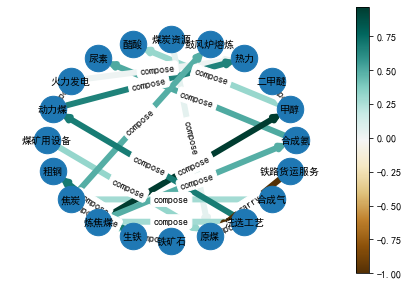

In [576]:
#pos = nx.spring_layout(G, seed=7,k=100/sqrt(len(G.nodes)))

pos=nx.circular_layout(G, dim=2)
#pos: dict for every nodes with 2d ndarray [0.999999988, 1.33118354e-08]
pos['合成氨']=[9.99999988e-01, 1.33118354e-08]
nx.draw_networkx_nodes(G, pos, node_size=700)
edge_colors=[d['velocity'] for (u, v, d) in G.edges(data=True) ]
cmap=plt.cm.BrBG
# edges
e = [(u, v) for (u, v, d) in G.edges(data=True) ]
draw_edges=nx.draw_networkx_edges(G, pos, edgelist=e, width=6,edge_color=edge_colors,edge_cmap=cmap)


# node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")
# edge weight labels
edge_labels = nx.get_edge_attributes(G, "relationship")
nx.draw_networkx_edge_labels(G, pos, edge_labels)

ax = plt.gca()
ax.margins(0.1)
plt.axis("off")
plt.tight_layout()
pc = mpl.collections.PatchCollection(draw_edges, cmap=cmap)
pc.set_array(edge_colors)

ax = plt.gca()
ax.set_axis_off()
plt.colorbar(pc)
plt.show()

In [278]:
[d['velocity'] for (u, v, d) in G.edges(data=True) ]

[0.004401143305187372,
 0.6676465347807793,
 0.9223832911999494,
 0.959632030739519,
 0.2737904495814151,
 0.14009865083329665,
 0.026093818751220077,
 0.7303699312374933,
 0.41397488278912764,
 0.6268510153557446,
 0.2651379298872115,
 0.9959422361732042,
 0.5437365096730532,
 0.993163372522446,
 0.9546708687536231,
 0.03128433088410432,
 0.010835054816161094,
 0.2726604594934341,
 0.19071358105639236,
 0.2572486142190711]

In [146]:
pos

{'合成氨': [0.999999988, 1.33118354e-08],
 '甲醇': array([0.95105653, 0.30901701]),
 '二甲醚': array([0.80901699, 0.58778525]),
 '热力': array([0.58778524, 0.80901701]),
 '鼓风炉熔炼': array([0.30901697, 0.95105654]),
 '煤炭资源': array([-4.21220623e-08,  1.00000000e+00]),
 '醋酸': array([-0.30901703,  0.95105648]),
 '尿素': array([-0.58778523,  0.80901701]),
 '火力发电': array([-0.80901699,  0.58778525]),
 '动力煤': array([-0.95105647,  0.30901704]),
 '煤矿用设备': array([-9.99999985e-01, -7.41109400e-08]),
 '粗钢': array([-0.95105653, -0.30901696]),
 '焦炭': array([-0.80901693, -0.58778528]),
 '炼焦煤': array([-0.58778506, -0.8090171 ]),
 '生铁': array([-0.30901712, -0.95105645]),
 '铁矿石': array([ 1.35142058e-08, -9.99999973e-01]),
 '原煤': array([ 0.30901712, -0.95105645]),
 '洗选工艺': array([ 0.58778506, -0.8090171 ]),
 '合成气': array([ 0.80901693, -0.58778528]),
 '铁路货运服务': array([ 0.95105653, -0.30901693])}

In [26]:
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #该语句解决图像中的“-”负号的乱码问题

In [599]:
class Backbone_handler():
    def __init__(self,G:nx.Graph):
        self.G=G

    def nodes_group_by_label(self):
        G=self.G
        self.product={}
        self.company={}
        self.technique={}
        self.nodes={'product':self.product,'company':self.company,'technique':self.technique}
        for node,attr in G.nodes(True):
            labels=attr['labels(n)']
            if 'Product' in labels:
                self.product[node]=attr
            elif 'Company' in labels:
                self.company[node]=attr
            elif 'Technique' in labels:
                self.technique[node]=attr
        
    def edges_group_by_rela(self):
        G=self.G
        self.carry=[]
        self.compose=[]
        self.edges={'compose':self.compose,'carry':self.carry}
        for s,e,attr in G.edges(data=True):
            rela=attr['relationship']
            if 'compose' in rela:
                self.compose.append((s,e,attr))
            if 'carry' in rela:
                self.carry.append((s,e,attr))

    def draw_graph(self):
        cmap=plt.cm.winter_r
        self.nodes_group_by_label()
        self.edges_group_by_rela()
        #pos=nx.spring_layout(G,k=1/sqrt(len(self.G.nodes)),weight=None,scale=1,seed=20)
        pos=nx.spring_layout(self.G,k=1e4/self.G.number_of_nodes(),weight='velocity',scale=1,seed=1,iterations=10000,threshold=1e-15)
        #pos: dict for every nodes with 2d ndarray [0.999999988, 1.33118354e-08]
        #pos['合成氨']=[9.99999988e-01, 1.33118354e-08]
        fig, ax = plt.subplots(dpi=200)
        for label,nodes in self.nodes.items():
            if label=='product':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"o",}
            #print(draw_args)
            elif label=='technique':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"v",}
            nx.draw_networkx_nodes(G, pos=pos,ax=ax, **draw_args)

        # edges
        
        edge_colors=[]
        for rela,edges in self.edges.items():
                
            e = [(u, v) for (u, v, d) in edges ]
            colors=[d['velocity'] for (u, v, d) in edges ]
            draw_args={'width':6,'edge_color':"k",'style':"solid",'alpha':None,'arrowstyle':"-|>",'arrowsize':10,'label':None,'edge_color':colors,'edge_cmap':cmap}
            nx.draw_networkx_edges(G, pos, edgelist=e, ax=ax,**draw_args)
            edge_colors+=colors
        #edge_colors=[d['velocity'] for (u, v, d) in G.edges(data=True) ]
        
        # node labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif",ax=ax)
        # edge weight labels
        edge_labels = nx.get_edge_attributes(G, "velocity")
        edge_labels={k:round(v,2) for k,v in edge_labels.items()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels,ax=ax)

        ax = plt.gca()
        ax.margins(0.1)
        plt.axis("off")
        plt.tight_layout()
        pc = mpl.collections.PatchCollection(draw_edges, cmap=cmap)
        pc.set_array(edge_colors)

        ax = plt.gca()
        #ax.set_axis_off()
        plt.colorbar(pc,ax=ax)
        plt.show()
        return(draw_edges)
    def export_json(self):
        pass

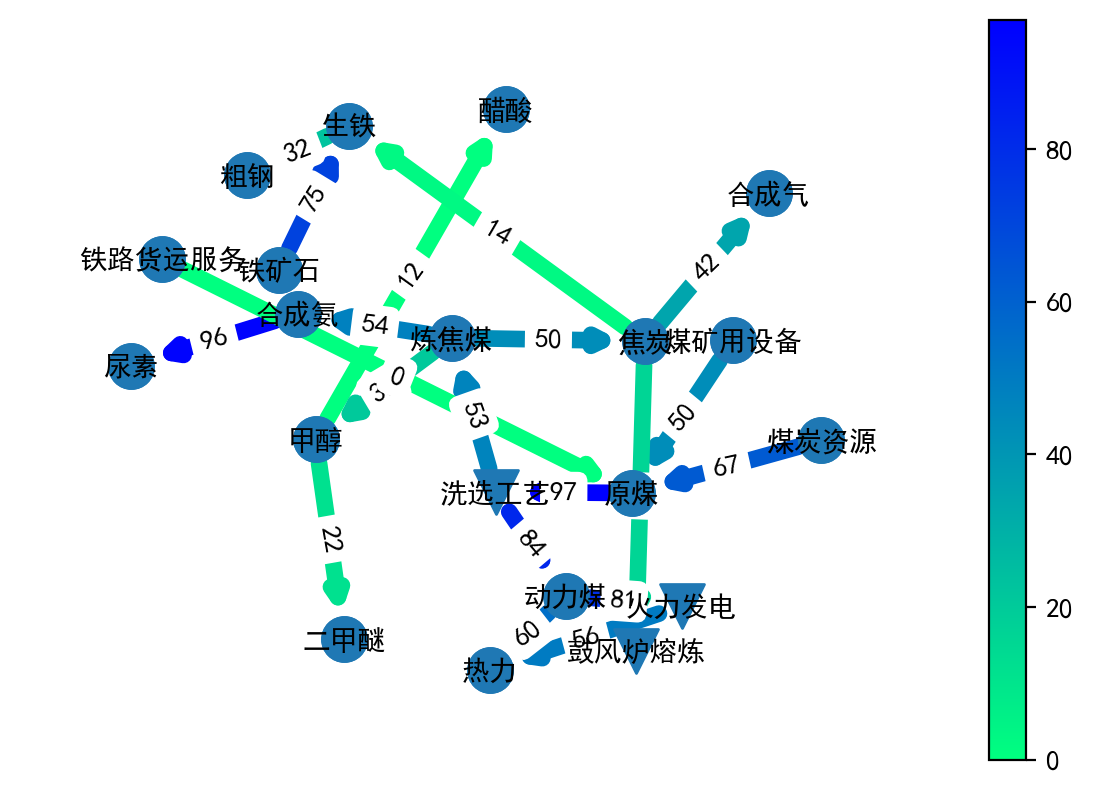

In [600]:
a=Backbone_handler(G)
e=a.draw_graph()

In [607]:
import copy

node_json=[]
for n in copy.deepcopy(G.nodes(data=True)):
    name,attr=n
    attr['name']=name
    attr['labels']=attr.pop('labels(n)')
    node_json.append(attr)
edge_json=[]
for e in copy.deepcopy(G.edges(data=True)):
    s,end,attr=e
    attr['source']=s
    attr['target']=end
    
    edge_json.append(attr)
#node_json=json.dumps(node_json)
#edge_json=json.dumps(edge_json)
data=json.dumps({'nodes':node_json,'links':edge_json},ensure_ascii=False)
data

'{"nodes": [{"stock": 50, "name": "合成氨", "labels": ["Product"]}, {"stock": 87, "name": "甲醇", "labels": ["Product"]}, {"stock": 22, "name": "二甲醚", "labels": ["Product"]}, {"stock": 39, "name": "热力", "labels": ["Product"]}, {"stock": 0, "name": "鼓风炉熔炼", "labels": ["Technique"]}, {"stock": 27, "name": "煤炭资源", "labels": ["Product"]}, {"stock": 32, "name": "醋酸", "labels": ["Product"]}, {"stock": 68, "name": "尿素", "labels": ["Product"]}, {"stock": 0, "name": "火力发电", "labels": ["Technique"]}, {"stock": 66, "name": "动力煤", "labels": ["Product"]}, {"stock": 97, "name": "煤矿用设备", "labels": ["Product"]}, {"stock": 19, "name": "粗钢", "labels": ["Product"]}, {"stock": 30, "name": "焦炭", "labels": ["Product"]}, {"stock": 85, "name": "炼焦煤", "labels": ["Product"]}, {"stock": 17, "name": "生铁", "labels": ["Product"]}, {"stock": 87, "name": "铁矿石", "labels": ["Product"]}, {"stock": 94, "name": "原煤", "labels": ["Product"]}, {"stock": 0, "name": "洗选工艺", "labels": ["Technique"]}, {"stock": 20, "name": "合成气", "la

In [585]:
for n in G.nodes(data=True):
    print(n)

('合成氨', {'labels(n)': ['Product']})
('甲醇', {'labels(n)': ['Product']})
('二甲醚', {'labels(n)': ['Product']})
('热力', {'labels(n)': ['Product']})
('鼓风炉熔炼', {'labels(n)': ['Technique']})
('煤炭资源', {'labels(n)': ['Product']})
('醋酸', {'labels(n)': ['Product']})
('尿素', {'labels(n)': ['Product']})
('火力发电', {'labels(n)': ['Technique']})
('动力煤', {'labels(n)': ['Product']})
('煤矿用设备', {'labels(n)': ['Product']})
('粗钢', {'labels(n)': ['Product']})
('焦炭', {'labels(n)': ['Product']})
('炼焦煤', {'labels(n)': ['Product']})
('生铁', {'labels(n)': ['Product']})
('铁矿石', {'labels(n)': ['Product']})
('原煤', {'labels(n)': ['Product']})
('洗选工艺', {'labels(n)': ['Technique']})
('合成气', {'labels(n)': ['Product']})
('铁路货运服务', {'labels(n)': ['Product']})


In [540]:
def build_json(nodes,edges):
    pass
a=nodes[0]
n=json.dumps([dict(zip(a.keys(),a.values())) for a in nodes])
e=json.dumps()

'[{"n.name": "\\u5408\\u6210\\u6c28", "labels(n)": ["Product"]}, {"n.name": "\\u7532\\u9187", "labels(n)": ["Product"]}, {"n.name": "\\u4e8c\\u7532\\u919a", "labels(n)": ["Product"]}, {"n.name": "\\u70ed\\u529b", "labels(n)": ["Product"]}, {"n.name": "\\u9f13\\u98ce\\u7089\\u7194\\u70bc", "labels(n)": ["Technique"]}, {"n.name": "\\u7164\\u70ad\\u8d44\\u6e90", "labels(n)": ["Product"]}, {"n.name": "\\u918b\\u9178", "labels(n)": ["Product"]}, {"n.name": "\\u5c3f\\u7d20", "labels(n)": ["Product"]}, {"n.name": "\\u706b\\u529b\\u53d1\\u7535", "labels(n)": ["Technique"]}, {"n.name": "\\u52a8\\u529b\\u7164", "labels(n)": ["Product"]}, {"n.name": "\\u7164\\u77ff\\u7528\\u8bbe\\u5907", "labels(n)": ["Product"]}, {"n.name": "\\u7c97\\u94a2", "labels(n)": ["Product"]}, {"n.name": "\\u7126\\u70ad", "labels(n)": ["Product"]}, {"n.name": "\\u70bc\\u7126\\u7164", "labels(n)": ["Product"]}, {"n.name": "\\u751f\\u94c1", "labels(n)": ["Product"]}, {"n.name": "\\u94c1\\u77ff\\u77f3", "labels(n)": ["Produ

In [541]:
edges

[<Record startNode(r).name='合成氨' endNode(r).name='尿素' type(r)='compose'>,
 <Record startNode(r).name='甲醇' endNode(r).name='醋酸' type(r)='compose'>,
 <Record startNode(r).name='甲醇' endNode(r).name='二甲醚' type(r)='compose'>,
 <Record startNode(r).name='煤炭资源' endNode(r).name='原煤' type(r)='compose'>,
 <Record startNode(r).name='火力发电' endNode(r).name='热力' type(r)='compose'>,
 <Record startNode(r).name='动力煤' endNode(r).name='火力发电' type(r)='compose'>,
 <Record startNode(r).name='动力煤' endNode(r).name='热力' type(r)='compose'>,
 <Record startNode(r).name='煤矿用设备' endNode(r).name='原煤' type(r)='compose'>,
 <Record startNode(r).name='焦炭' endNode(r).name='生铁' type(r)='compose'>,
 <Record startNode(r).name='焦炭' endNode(r).name='合成气' type(r)='compose'>,
 <Record startNode(r).name='焦炭' endNode(r).name='鼓风炉熔炼' type(r)='compose'>,
 <Record startNode(r).name='炼焦煤' endNode(r).name='甲醇' type(r)='compose'>,
 <Record startNode(r).name='炼焦煤' endNode(r).name='合成氨' type(r)='compose'>,
 <Record startNode(r).name='炼焦煤

In [153]:
for k,v in a.nodes.items():
    print(v)

{'合成氨': {'labels(n)': ['Product']}, '甲醇': {'labels(n)': ['Product']}, '二甲醚': {'labels(n)': ['Product']}, '热力': {'labels(n)': ['Product']}, '煤炭资源': {'labels(n)': ['Product']}, '醋酸': {'labels(n)': ['Product']}, '尿素': {'labels(n)': ['Product']}, '动力煤': {'labels(n)': ['Product']}, '煤矿用设备': {'labels(n)': ['Product']}, '粗钢': {'labels(n)': ['Product']}, '焦炭': {'labels(n)': ['Product']}, '炼焦煤': {'labels(n)': ['Product']}, '生铁': {'labels(n)': ['Product']}, '铁矿石': {'labels(n)': ['Product']}, '原煤': {'labels(n)': ['Product']}, '合成气': {'labels(n)': ['Product']}, '铁路货运服务': {'labels(n)': ['Product']}}
{}
{}


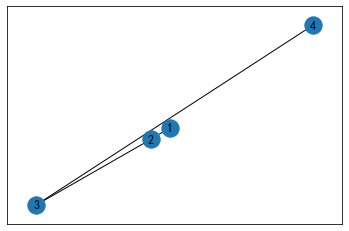

In [516]:
G=nx.Graph()
G.add_edge(1,2,velocity=100)
G.add_edge(2,3,velocity=1)
G.add_edge(3,4,velocity=-50)
nx.draw_networkx(G,pos=nx.spring_layout(G,weight='velocity'))

In [522]:
import json
with open(r'E:\wangzhilin\QuantumGalaxy\backbone\data.json','r') as f:
    data=json.load(f)

In [523]:
data

{'nodes': [{'name': '中广核风电', 'category': '公司', 'isroots': False},
  {'name': '东方电缆', 'category': '公司', 'isroots': False},
  {'name': '陶氏化学', 'category': '公司', 'isroots': False},
  {'name': '中天科技', 'category': '公司', 'isroots': False},
  {'name': '海上风电场', 'category': '产品', 'isroots': False, 'parents': ['风电厂']},
  {'name': '海洋线缆', 'category': '产品', 'isroots': False},
  {'name': '绝缘材料', 'category': '产品', 'isroots': False},
  {'name': '紫光股份', 'category': '公司', 'isroots': False},
  {'name': '慕晨科技', 'category': '公司', 'isroots': False},
  {'name': '俄速通', 'category': '公司', 'isroots': False},
  {'name': 'AVENT TECHNOLOGY HONG KONG LIMITED',
   'category': '公司',
   'isroots': False},
  {'name': '艾瑞电子中国有限公司', 'category': '公司', 'isroots': False},
  {'name': '艾为电子', 'category': '公司', 'isroots': False},
  {'name': '万润科技', 'category': '公司', 'isroots': False},
  {'name': '全志科技', 'category': '公司', 'isroots': False},
  {'name': '东菀力嘉', 'category': '公司', 'isroots': False},
  {'name': '信泰光学', 'category': '

In [524]:
data['links']

[{'name': '锌_原材料_金属膜', 'source': '锌', 'target': '金属膜', 'category': '原材料'},
 {'name': '铝锭_原材料_铝电解电容器',
  'source': '铝锭',
  'target': '铝电解电容器',
  'category': '原材料'},
 {'name': '艾瑞电子中国有限公司_供应_石头科技',
  'source': '艾瑞电子中国有限公司',
  'target': '石头科技',
  'category': '供应'},
 {'name': '电池包_原材料_储能电池系统',
  'source': '电池包',
  'target': '储能电池系统',
  'category': '原材料'},
 {'name': '智能应用处理器芯片设计_原材料_智能应用处理器芯片',
  'source': '智能应用处理器芯片设计',
  'target': '智能应用处理器芯片',
  'category': '原材料'},
 {'name': '中国铁塔_生产_通信基站',
  'source': '中国铁塔',
  'target': '通信基站',
  'category': '生产'},
 {'name': '肖特_生产_中硼硅玻璃', 'source': '肖特', 'target': '中硼硅玻璃', 'category': '生产'},
 {'name': '山东药玻_生产_中硼硅玻璃',
  'source': '山东药玻',
  'target': '中硼硅玻璃',
  'category': '生产'},
 {'name': '金赛药业_生产_长效生长激素',
  'source': '金赛药业',
  'target': '长效生长激素',
  'category': '生产'},
 {'name': '金赛药业_生产_水针生长激素',
  'source': '金赛药业',
  'target': '水针生长激素',
  'category': '生产'},
 {'name': '金赛药业_生产_粉针生长激素',
  'source': '金赛药业',
  'target': '粉针生长激素',
  'category': '生产'},
 {'na